In [1]:
import pandas as pd
import numpy as np
import os

# Install Kaggle library if not already installed
!pip install -q kaggle

# Create a .kaggle directory and move kaggle.json there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
# The dataset is 'creditcardfraud' from the 'mlg-ulb' user
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Unzip the downloaded file
!unzip creditcardfraud.zip

# Load the dataset
try:
    df = pd.read_csv('creditcard.csv')
    print("Dataset loaded successfully from 'creditcard.csv'.")
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please ensure it was downloaded and unzipped correctly.")
    df = None # Set df to None to indicate failure

# Display the first few rows and info of the loaded dataset
if df is not None:
    print("\nDataset Head:")
    print(df.head())
    print("\nDataset Info:")
    df.info()
    print("\nClass Distribution:")
    print(df['Class'].value_counts(normalize=True))



cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 96.5MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
Dataset loaded successfully from 'creditcard.csv'.

Dataset Head:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.0183

## Part 1: Data Quality & Reconciliation Layer

This section focuses on simulating real-world data reconciliation by creating two versions of our dataset: a 'system record' and a 'reference record'. We will intentionally inject various discrepancies into these datasets to mimic common data quality issues found in banking operations. Following this, a reconciliation function will be developed to identify and flag these discrepancies.

In [3]:
# Add a unique transaction ID for reconciliation
df['transaction_id'] = df.index

# Make copies for system and reference records
df_system = df.copy()
df_reference = df.copy()

np.random.seed(42) # for reproducibility

# --- Injecting Discrepancies ---

# 1. Mismatched Amounts (approx 5% of transactions)
num_mismatch_amount = int(len(df) * 0.05)
mismatch_indices = np.random.choice(df.index, num_mismatch_amount, replace=False)
df_system.loc[mismatch_indices, 'Amount'] = df_system.loc[mismatch_indices, 'Amount'] * np.random.uniform(0.9, 1.1, num_mismatch_amount)
df_system.loc[mismatch_indices, 'Amount'] = df_system.loc[mismatch_indices, 'Amount'].round(2)

# 2. Missing Fields (Amount set to NaN in system record for 2% of transactions)
num_missing_amount = int(len(df) * 0.02)
missing_amount_indices = np.random.choice(df.index, num_missing_amount, replace=False)
df_system.loc[missing_amount_indices, 'Amount'] = np.nan

# 3. Duplicate Entries (Add 1% of transactions as duplicates to the system record)
num_duplicates = int(len(df) * 0.01)
duplicate_indices = np.random.choice(df.index, num_duplicates, replace=True) # allow sampling with replacement for duplicates
df_system = pd.concat([df_system, df.loc[duplicate_indices]], ignore_index=True)

# 4. Stale Timestamps (Modify 'Time' for 3% of transactions in system record)
num_stale_time = int(len(df) * 0.03)
stale_time_indices = np.random.choice(df.index, num_stale_time, replace=False)
df_system.loc[stale_time_indices, 'Time'] = df_system.loc[stale_time_indices, 'Time'] + np.random.randint(60, 3600, num_stale_time) # add 1 to 60 minutes

# 5. Missing Transactions (Remove 1% of transactions from the reference record)
num_missing_transactions = int(len(df) * 0.01)
missing_transaction_indices = np.random.choice(df.index, num_missing_transactions, replace=False)
df_reference = df_reference.drop(index=missing_transaction_indices)

print(f"Original dataset shape: {df.shape}")
print(f"System record shape after discrepancies: {df_system.shape}")
print(f"Reference record shape after discrepancies: {df_reference.shape}")

print("\nSample of df_system with discrepancies (head and tail to show potential duplicates/altered times):")
print(df_system.head())
print(df_system.tail())

print("\nSample of df_reference (head to show structure, some transactions may be missing in between):")
print(df_reference.head())

Original dataset shape: (284807, 32)
System record shape after discrepancies: (287655, 32)
Reference record shape after discrepancies: (281959, 32)

Sample of df_system with discrepancies (head and tail to show potential duplicates/altered times):
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
2  0.247676 -1.514654  ..

In [5]:
def reconcile_transactions(system_df, reference_df, id_col='transaction_id', reconcile_cols=None):
    """
    Compares two transaction DataFrames (system and reference) and flags discrepancies.

    Args:
        system_df (pd.DataFrame): DataFrame representing the system's record.
        reference_df (pd.DataFrame): DataFrame representing the trusted reference record.
        id_col (str): The column name used as a unique transaction identifier.
        reconcile_cols (list): List of columns to compare for mismatches.
                               If None, all common columns (excluding id_col and 'Class') are reconciled.

    Returns:
        tuple: A tuple containing:
            - reconciliation_report (pd.DataFrame): A DataFrame summarizing all flagged discrepancies.
            - reconciled_df (pd.DataFrame): A merged DataFrame containing reconciled transactions
                                            and flags for review.
    """
    report_entries = []

    # --- 1. Identify transactions missing in either system ---
    system_ids = set(system_df[id_col].unique())
    reference_ids = set(reference_df[id_col].unique())

    # Transactions in reference but not in system
    missing_in_system_ids = list(reference_ids - system_ids)
    if missing_in_system_ids:
        for tid in missing_in_system_ids:
            report_entries.append({
                'transaction_id': tid,
                'discrepancy_type': 'Missing Transaction',
                'severity': 'Critical',
                'description': f'Transaction {tid} found in reference but missing in system.'
            })

    # Transactions in system but not in reference (could be new, or actual discrepancy)
    missing_in_reference_ids = list(system_ids - reference_ids)
    if missing_in_reference_ids:
        for tid in missing_in_reference_ids:
            report_entries.append({
                'transaction_id': tid,
                'discrepancy_type': 'Unmatched Transaction',
                'severity': 'Warning',
                'description': f'Transaction {tid} found in system but missing in reference.'
            })

    # --- 2. Merge dataframes for comparison of common transactions ---
    # Use an outer merge to catch all transactions for comprehensive comparison
    merged_df = pd.merge(system_df, reference_df, on=id_col, how='outer', suffixes=('_sys', '_ref'))

    # Filter to only consider transactions present in both for detailed comparison
    common_transactions_df = merged_df.dropna(subset=[col + '_sys' for col in system_df.drop(columns=[id_col, 'Class'], errors='ignore').columns] + [col + '_ref' for col in reference_df.drop(columns=[id_col, 'Class'], errors='ignore').columns], how='all')

    # Determine columns to reconcile
    if reconcile_cols is None:
        # Exclude 'Class' as it's a target variable for fraud, not a reconciliation field
        all_common_cols = list(set(system_df.columns) & set(reference_df.columns) - {id_col, 'Class'})
        reconcile_cols = [col for col in all_common_cols if col not in [id_col, 'Class']]

    # --- 3. Identify duplicates in the system_df ---
    # Group by all columns (excluding the new transaction_id if it's just index) to find true duplicates
    # For this exercise, duplicates were injected as entire rows from original df
    # We need to consider df_system duplicates using original columns.
    original_cols = [col for col in system_df.columns if col not in ['transaction_id']]
    duplicates = system_df[system_df.duplicated(subset=original_cols, keep=False)]

    if not duplicates.empty:
        # Only report each unique duplicate transaction_id once
        for tid in duplicates[id_col].unique():
            report_entries.append({
                'transaction_id': tid,
                'discrepancy_type': 'Duplicate Entry',
                'severity': 'Critical',
                'description': f'Transaction {tid} has duplicate entries in the system record.'
            })

    # --- 4. Compare fields for common transactions ---
    for col in reconcile_cols:
        sys_col = col + '_sys'
        ref_col = col + '_ref'

        # Handle missing fields (NaNs) in merged common_transactions_df
        missing_in_sys_mask = common_transactions_df[sys_col].isnull() & common_transactions_df[ref_col].notnull()
        for tid in common_transactions_df.loc[missing_in_sys_mask, id_col].unique():
            report_entries.append({
                'transaction_id': tid,
                'discrepancy_type': f'Missing Field: {col}',
                'severity': 'Critical',
                'description': f'Field "{col}" is missing in system for transaction {tid}.'
            })

        missing_in_ref_mask = common_transactions_df[ref_col].isnull() & common_transactions_df[sys_col].notnull()
        for tid in common_transactions_df.loc[missing_in_ref_mask, id_col].unique():
            report_entries.append({
                'transaction_id': tid,
                'discrepancy_type': f'Missing Field: {col}',
                'severity': 'Warning',
                'description': f'Field "{col}" is missing in reference for transaction {tid}.'
            })

        # Compare non-missing values
        comparison_mask = common_transactions_df[sys_col].notnull() & common_transactions_df[ref_col].notnull()

        if col == 'Amount':
            # For amounts, allow a small tolerance due to potential floating point inaccuracies
            mismatch_mask = comparison_mask & ~np.isclose(common_transactions_df[sys_col], common_transactions_df[ref_col], atol=0.01) # 0.01 tolerance
            severity = 'Critical'
            desc_template = f'Amount mismatch for transaction {{tid}}: System={{sys_val}}, Reference={{ref_val}}.'
        elif col == 'Time':
            # For time, flag if values are not exactly equal (or within a very small tolerance)
            mismatch_mask = comparison_mask & (common_transactions_df[sys_col] != common_transactions_df[ref_col])
            severity = 'Warning' # Stale timestamp might be a warning, not critical unless difference is large
            desc_template = f'Timestamp mismatch for transaction {{tid}}: System={{sys_val}}, Reference={{ref_val}}.'
        else:
            mismatch_mask = comparison_mask & (common_transactions_df[sys_col] != common_transactions_df[ref_col])
            severity = 'Critical'
            desc_template = f'Field "{col}" mismatch for transaction {{tid}}: System={{sys_val}}, Reference={{ref_val}}.'

        for tid in common_transactions_df.loc[mismatch_mask, id_col].unique():
            sys_val = common_transactions_df.loc[common_transactions_df[id_col] == tid, sys_col].iloc[0]
            ref_val = common_transactions_df.loc[common_transactions_df[id_col] == tid, ref_col].iloc[0]
            report_entries.append({
                'transaction_id': tid,
                'discrepancy_type': f'Value Mismatch: {col}',
                'severity': severity,
                'description': desc_template.format(tid=tid, sys_val=sys_val, ref_val=ref_val)
            })

    reconciliation_report = pd.DataFrame(report_entries)
    # Add a 'flagged' column to the merged_df for easier filtering later
    merged_df['is_flagged'] = merged_df[id_col].isin(reconciliation_report['transaction_id'])

    return reconciliation_report, merged_df

# Define columns to reconcile (excluding 'Class' and V-features for this step as they are PCA features and less directly reconcilable for specific 'value mismatches')
reconciliation_features = ['Time', 'Amount']

# Perform reconciliation
reconciliation_report_df, reconciled_transactions_df = reconcile_transactions(df_system, df_reference, reconcile_cols=reconciliation_features)

print("Reconciliation Report:")
print(reconciliation_report_df.head(10))
print(f"\nTotal discrepancies found: {len(reconciliation_report_df)}")
print(reconciliation_report_df['discrepancy_type'].value_counts())
print(reconciliation_report_df['severity'].value_counts())

print("\nReconciled Transactions DataFrame (first 5 flagged rows):")
print(reconciled_transactions_df[reconciled_transactions_df['is_flagged']].head())

Reconciliation Report:
   transaction_id       discrepancy_type severity  \
0           49155  Unmatched Transaction  Warning   
1          237575  Unmatched Transaction  Warning   
2          139272  Unmatched Transaction  Warning   
3          213001  Unmatched Transaction  Warning   
4          213008  Unmatched Transaction  Warning   
5            8213  Unmatched Transaction  Warning   
6          139287  Unmatched Transaction  Warning   
7          163866  Unmatched Transaction  Warning   
8           40988  Unmatched Transaction  Warning   
9          180252  Unmatched Transaction  Warning   

                                         description  
0  Transaction 49155 found in system but missing ...  
1  Transaction 237575 found in system but missing...  
2  Transaction 139272 found in system but missing...  
3  Transaction 213001 found in system but missing...  
4  Transaction 213008 found in system but missing...  
5  Transaction 8213 found in system but missing i...  
6  Trans

## Part 2: Fraud/Anomaly Detection

This section focuses on building and evaluating a fraud detection system using the prepared `df` (original, clean dataset). We will address the class imbalance, train various models, and evaluate their performance using appropriate metrics for imbalanced datasets.

--- Class Distribution ---
Class
0    284315
1       492
Name: count, dtype: int64
Non-Fraudulent: 284315 (99.83%)
Fraudulent: 492 (0.17%)



/tmp/ipykernel_834/1124421742.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


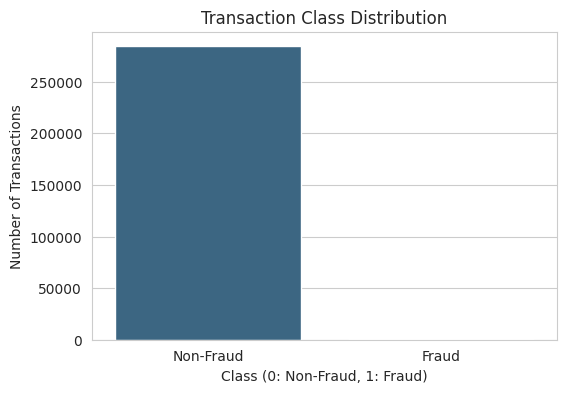

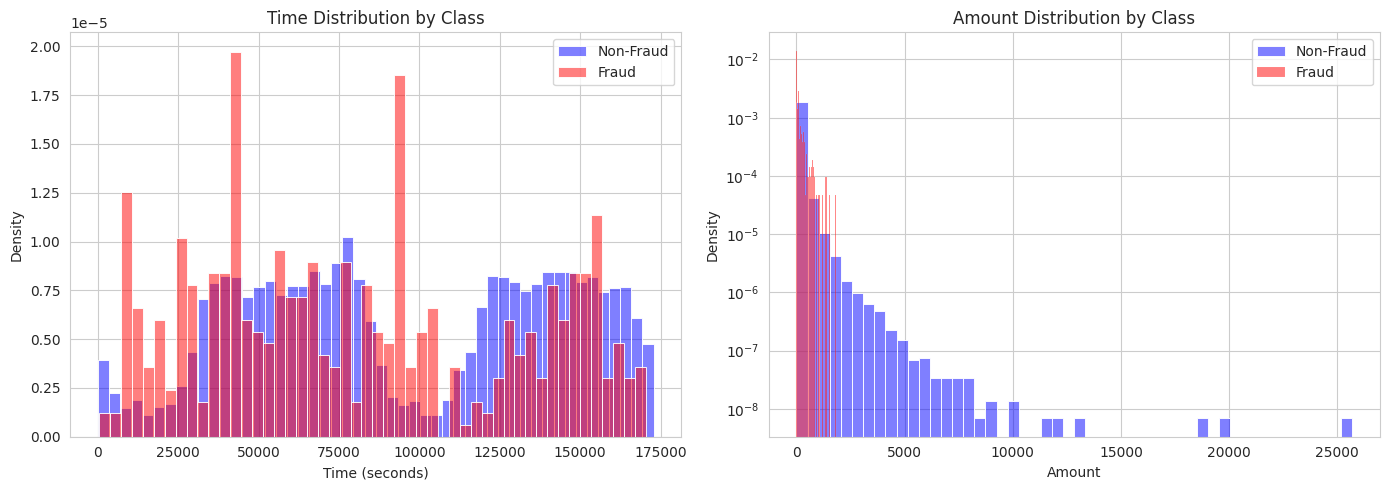

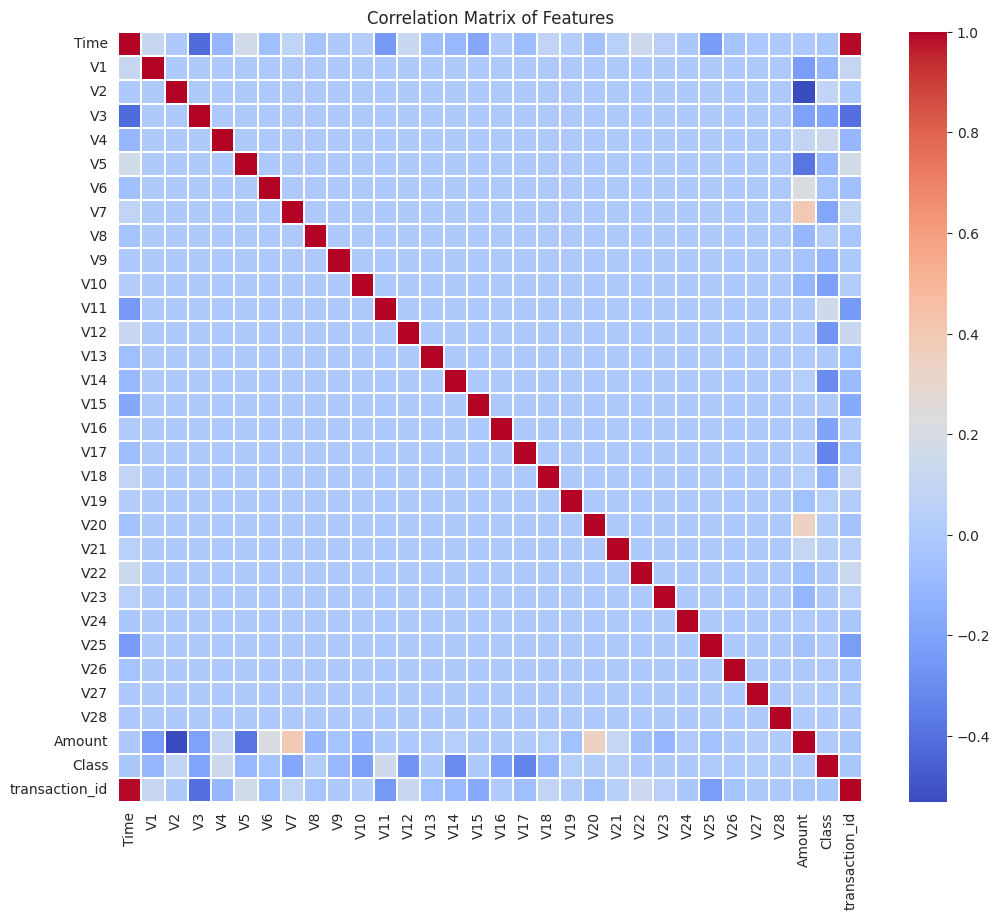


--- Top Correlated Features with Class (Absolute Value) ---
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64


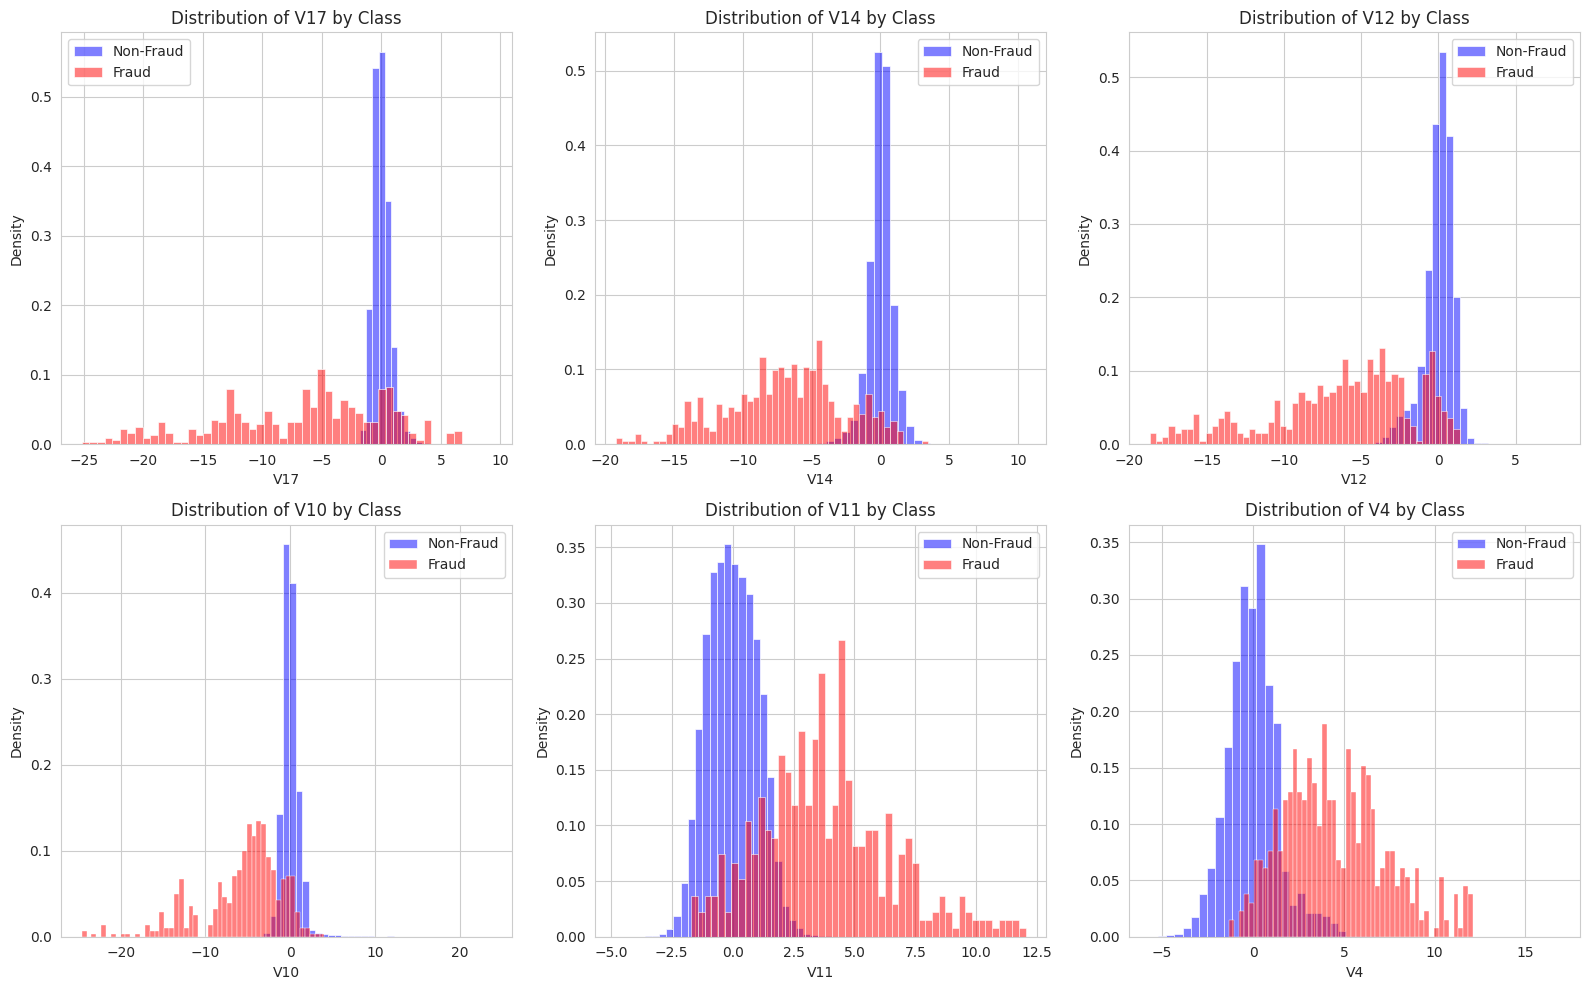

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

# 1. Class Imbalance
print("--- Class Distribution ---")
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"Non-Fraudulent: {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Fraudulent: {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)\n")

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Transaction Class Distribution')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud', 'Fraud'])
plt.show()

# 2. Distribution of Time and Amount for Fraud vs. Non-Fraud
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, color='blue', alpha=0.5, stat='density', label='Non-Fraud')
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, color='red', alpha=0.5, stat='density', label='Fraud')
plt.title('Time Distribution by Class')
plt.xlabel('Time (seconds)')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', alpha=0.5, stat='density', label='Non-Fraud')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.5, stat='density', label='Fraud')
plt.title('Amount Distribution by Class')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.yscale('log') # Log scale for better visibility of fraud transactions
plt.legend()
plt.tight_layout()
plt.show()

# 3. Correlation Matrix (focus on 'Amount', 'Time' and 'Class' with V-features if needed)
# Given the large number of V-features, we can look at correlation with 'Class' directly.

plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Matrix of Features')
plt.show()

print("\n--- Top Correlated Features with Class (Absolute Value) ---")
print(correlation_matrix['Class'].abs().sort_values(ascending=False).head(10))

# Individual feature distributions for some V-features that are highly correlated with 'Class'
# Example: V17, V14, V12, V10 (highly negatively correlated with fraud)
# V11, V4 (highly positively correlated with fraud)
high_corr_features = ['V17', 'V14', 'V12', 'V10', 'V11', 'V4']

plt.figure(figsize=(16, 10))
for i, col in enumerate(high_corr_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[df['Class'] == 0][col], bins=50, color='blue', alpha=0.5, stat='density', label='Non-Fraud')
    sns.histplot(df[df['Class'] == 1][col], bins=50, color='red', alpha=0.5, stat='density', label='Fraud')
    plt.title(f'Distribution of {col} by Class')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
plt.tight_layout()
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Drop transaction_id as it was used for reconciliation, not for fraud detection
X = df.drop(['Class', 'transaction_id'], axis=1)
y = df['Class']

# Split the dataset into training and testing sets first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original test set shape:", X_test.shape, y_test.shape)
print("Original training class distribution:\n", y_train.value_counts(normalize=True))

# Apply SMOTE to the training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nResampled training set shape:", X_train_res.shape, y_train_res.shape)
print("Resampled training class distribution:\n", y_train_res.value_counts(normalize=True))

print("Data preparation for model training complete. Training data has been balanced using SMOTE.")

Original training set shape: (227845, 30) (227845,)
Original test set shape: (56962, 30) (56962,)
Original training class distribution:
 Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Resampled training set shape: (454902, 30) (454902,)
Resampled training class distribution:
 Class
0    0.5
1    0.5
Name: proportion, dtype: float64
Data preparation for model training complete. Training data has been balanced using SMOTE.


### 2.3 Train and Compare at least Two Models

We will train a Logistic Regression and a Random Forest Classifier. Given the severe class imbalance, accuracy alone is misleading because a model that always predicts 'non-fraud' would achieve over 99% accuracy but fail to detect any fraud. Instead, we will focus on:

*   **Precision:** The proportion of positive identifications that were actually correct. (High precision means fewer false positives - important to reduce alert fatigue for investigators).
*   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly. (High recall means fewer false negatives - important to catch as much fraud as possible).
*   **F1-Score:** The harmonic mean of precision and recall, providing a single metric that balances both.
*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):** Measures the ability of a classifier to distinguish between classes. A higher AUC indicates a better model performance in separating fraudulent from non-fraudulent transactions.
*   **Confusion Matrix:** A table that describes the performance of a classification model on a set of test data for which the true values are known.


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(



--- Logistic Regression Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962


Confusion Matrix:


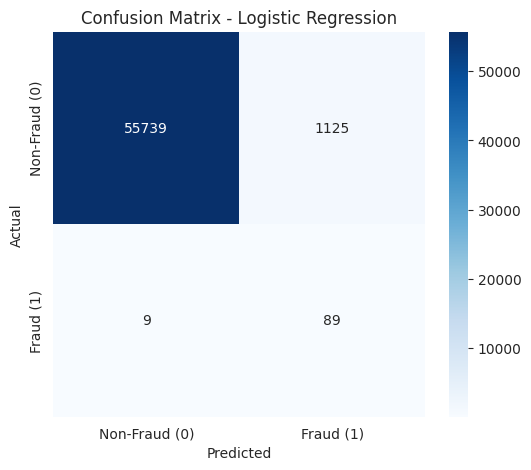

ROC-AUC Score: 0.9732


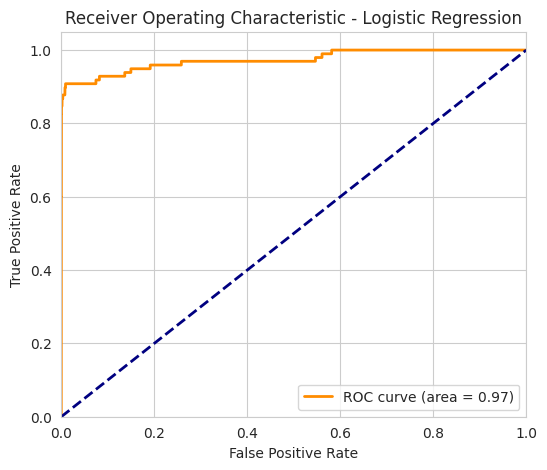

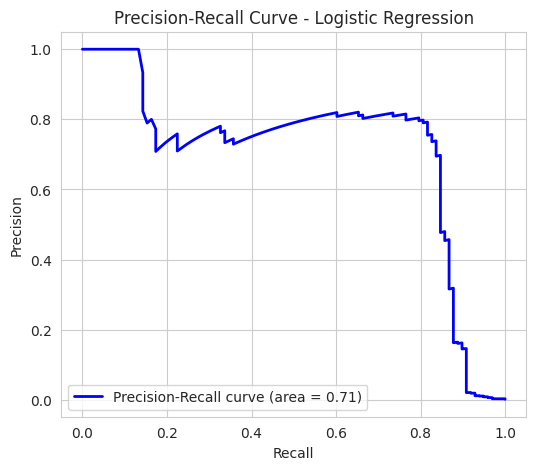


Training Random Forest Classifier...

--- Random Forest Classifier Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.52      0.89      0.66        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:


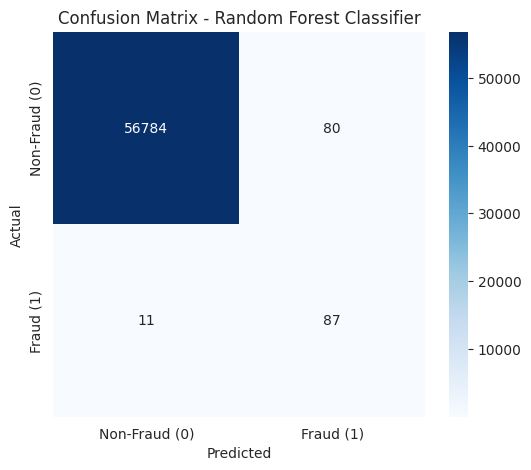

ROC-AUC Score: 0.9849


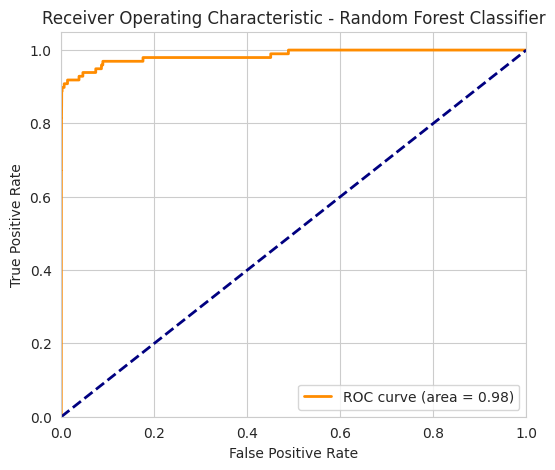

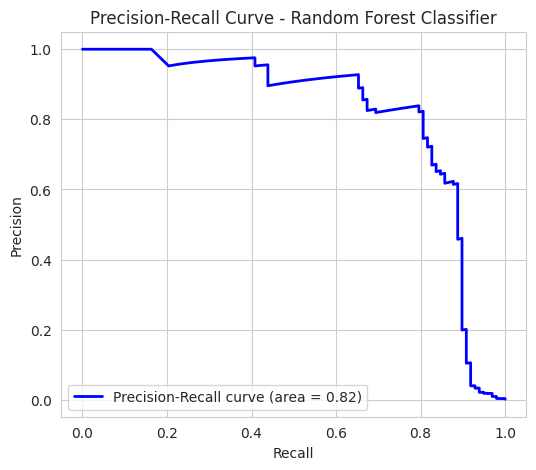


--- Random Forest Feature Importance ---


/tmp/ipykernel_834/3612101716.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(15).values, y=feature_importances.head(15).index, palette='viridis')


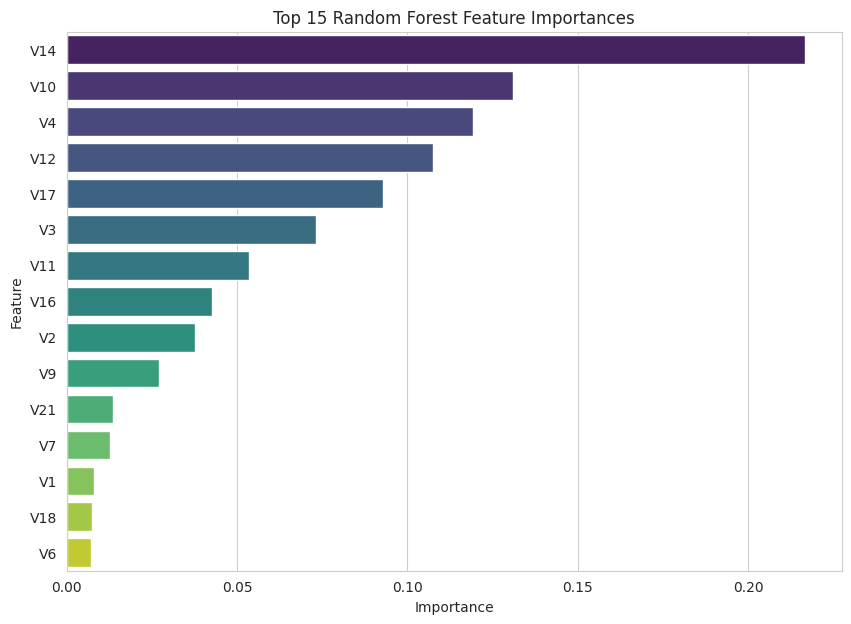

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to evaluate and plot results
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n--- {model_name} Evaluation ---")
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
                yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

    # Plot Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc="lower left")
    plt.show()

    return {'model_name': model_name, 'roc_auc': roc_auc, 'classification_report': classification_report(y_test, y_pred, output_dict=True)}

# --- Logistic Regression ---
print("\nTraining Logistic Regression...")
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1)
log_reg_model.fit(X_train_res, y_train_res)
log_reg_results = evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

# --- Random Forest Classifier ---
print("\nTraining Random Forest Classifier...")
# Use a smaller number of estimators and max_depth for quicker training in Colab, tune as needed
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf_model.fit(X_train_res, y_train_res)
rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest Classifier')

# Store results for final summary
all_model_results = [log_reg_results, rf_results]

# Feature Importance for Random Forest
print("\n--- Random Forest Feature Importance ---")
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances.head(15).values, y=feature_importances.head(15).index, palette='viridis')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [14]:
# This cell will run the previously defined code to train and evaluate models
# and is intentionally left empty as its content was part of the last code generation.

## Part 3: Monitoring Output

In this section, we will integrate the data reconciliation layer (Part 1) and the fraud detection model (Part 2) into a single, cohesive "daily monitoring report" function. This function will simulate processing new batches of transactions, identifying both data quality exceptions and fraud risks, and presenting them in a format ready for review by operational teams or fraud investigators.

In [18]:
def daily_monitoring_report(new_system_records, new_reference_records, model, feature_cols, reconciliation_cols, fraud_threshold=0.5):
    """
    Generates a daily monitoring report combining reconciliation and fraud flagging.

    Args:
        new_system_records (pd.DataFrame): New batch of system transaction records.
        new_reference_records (pd.DataFrame): New batch of reference transaction records.
        model: Trained fraud detection model (e.g., RandomForestClassifier).
        feature_cols (list): List of feature column names used for the model.
        reconciliation_cols (list): List of columns to reconcile.
        fraud_threshold (float): Probability threshold above which a transaction is flagged as high-risk fraud.

    Returns:
        tuple: A tuple containing:
            - reconciliation_exceptions (pd.DataFrame): DataFrame of reconciliation flags.
            - fraud_risk_transactions (pd.DataFrame): DataFrame of transactions flagged as high fraud risk.
    """
    print("\n--- Running Daily Monitoring Report ---")

    # --- Part 1: Reconciliation ---
    print("Performing data reconciliation...")
    # Ensure transaction_id is present for reconciliation
    if 'transaction_id' not in new_system_records.columns:
        new_system_records['transaction_id'] = new_system_records.index
    if 'transaction_id' not in new_reference_records.columns:
        new_reference_records['transaction_id'] = new_reference_records.index

    reconciliation_exceptions, _ = reconcile_transactions(
        new_system_records,
        new_reference_records,
        reconcile_cols=reconciliation_cols
    )
    print(f"Found {len(reconciliation_exceptions)} reconciliation exceptions.")

    # --- Part 2: Fraud Detection ---
    print("Scoring transactions for fraud risk...")

    # Prepare data for model prediction using the system records as the primary source
    # Ensure feature_cols exist in new_system_records and handle any missing ones (e.g., fill with 0 or mean)
    X_new = new_system_records[feature_cols].copy()
    # Handle any potential NaNs in the data that might have been introduced during discrepancy injection
    X_new = X_new.fillna(X_train.mean()) # Using mean from original training data

    # Predict fraud probabilities
    fraud_probabilities = model.predict_proba(X_new)[:, 1]

    # Add probabilities to the system records for output
    new_system_records['fraud_probability'] = fraud_probabilities

    # Flag transactions above the fraud threshold
    fraud_risk_transactions = new_system_records[new_system_records['fraud_probability'] >= fraud_threshold].copy()
    print(f"Found {len(fraud_risk_transactions)} transactions above fraud risk threshold ({fraud_threshold}).")

    # Sort by probability for investigator review
    fraud_risk_transactions = fraud_risk_transactions.sort_values(by='fraud_probability', ascending=False)

    print("Daily Monitoring Report complete.")
    return reconciliation_exceptions, fraud_risk_transactions

# --- Prepare dummy 'new' data for demonstration ---
# For demonstration, let's take a small random sample from the original df as 'new' data
# and inject some discrepancies for reconciliation to work.

# Create a fresh sample of the original data to simulate a new batch.
# We'll re-add transaction_id to this base for consistency with how reconciliation expects it.
new_batch_size = 1000
np.random.seed(99) # for reproducibility of the new batch

# Select a random sample of unique transaction_ids from the original df for the new batch
sample_indices = np.random.choice(df.index.unique(), new_batch_size, replace=False)
base_new_data = df.loc[sample_indices].copy()
base_new_data['transaction_id'] = base_new_data.index # Assign original index as transaction_id

# Simulate new system and reference records from this base
new_system_records_sim = base_new_data.copy()
new_reference_records_sim = base_new_data.copy()

# Inject some *new* discrepancies into this batch for reconciliation testing
# Mismatched Amounts (e.g., 10% of new batch)
num_mismatch_amount_new = int(len(base_new_data) * 0.1)
mismatch_indices_new = np.random.choice(base_new_data.index, num_mismatch_amount_new, replace=False)
new_system_records_sim.loc[mismatch_indices_new, 'Amount'] = new_system_records_sim.loc[mismatch_indices_new, 'Amount'] * np.random.uniform(0.8, 1.2, num_mismatch_amount_new)
new_system_records_sim.loc[mismatch_indices_new, 'Amount'] = new_system_records_sim.loc[mismatch_indices_new, 'Amount'].round(2)

# Missing Fields (e.g., 5% of new batch) in system records
num_missing_amount_new = int(len(base_new_data) * 0.05)
missing_amount_indices_new = np.random.choice(base_new_data.index, num_missing_amount_new, replace=False)
new_system_records_sim.loc[missing_amount_indices_new, 'Amount'] = np.nan

# Missing Transactions (e.g., 3% of new batch) from reference records
num_missing_ref_new = int(len(base_new_data) * 0.03)
missing_ref_indices_new = np.random.choice(base_new_data.index, num_missing_ref_new, replace=False)
new_reference_records_sim = new_reference_records_sim.drop(index=missing_ref_indices_new)

print(f"Simulated new batch original size: {base_new_data.shape[0]}")
print(f"Simulated new system records size: {new_system_records_sim.shape[0]}")
print(f"Simulated new reference records size: {new_reference_records_sim.shape[0]}")

# Define feature columns for the model (excluding 'Class' and 'transaction_id')
# Ensure these columns align with the ones used during model training
feature_cols = X.columns.tolist() # X was defined as df.drop(['Class', 'transaction_id'], axis=1)

# Run the daily monitoring report
reconciliation_exceptions, fraud_risk_transactions = daily_monitoring_report(
    new_system_records_sim,
    new_reference_records_sim,
    model=rf_model, # Using the better-performing Random Forest model
    feature_cols=feature_cols,
    reconciliation_cols=reconciliation_features # Using the same reconciliation features as before
)

print("\n--- Reconciliation Exceptions Report for New Batch ---")
print(reconciliation_exceptions.head(10))
print(f"Total reconciliation exceptions: {len(reconciliation_exceptions)}")
print(reconciliation_exceptions['discrepancy_type'].value_counts())

print("\n--- High-Risk Fraud Transactions Report for New Batch ---")
print(fraud_risk_transactions.head(10)[['transaction_id', 'Amount', 'fraud_probability', 'Class']])
print(f"Total high-risk fraud transactions: {len(fraud_risk_transactions)}")
print(f"Actual fraud in high-risk transactions: {fraud_risk_transactions['Class'].sum()}")

Simulated new batch original size: 1000
Simulated new system records size: 1000
Simulated new reference records size: 970

--- Running Daily Monitoring Report ---
Performing data reconciliation...
Found 218 reconciliation exceptions.
Scoring transactions for fraud risk...
Found 2 transactions above fraud risk threshold (0.5).
Daily Monitoring Report complete.

--- Reconciliation Exceptions Report for New Batch ---
   transaction_id       discrepancy_type severity  \
0           37121  Unmatched Transaction  Warning   
1           25213  Unmatched Transaction  Warning   
2          201994  Unmatched Transaction  Warning   
3          116885  Unmatched Transaction  Warning   
4            6687  Unmatched Transaction  Warning   
5           90914  Unmatched Transaction  Warning   
6           19751  Unmatched Transaction  Warning   
7          112553  Unmatched Transaction  Warning   
8           51116  Unmatched Transaction  Warning   
9          258614  Unmatched Transaction  Warning   

## Part 4: Final Summary and Conclusion

This section provides a summary of the fraud detection model performance and outlines the overall capabilities of the Transaction Reconciliation & Fraud Exception Flagging System.

### 4.1 Fraud Detection Model Performance Summary

Below are the key metrics for the Logistic Regression and Random Forest models trained on the SMOTE-resampled data and evaluated on the original, imbalanced test set. We focus on Precision, Recall, F1-Score for the fraudulent class (Class 1), and ROC-AUC score, as these are more appropriate for highly imbalanced datasets than overall accuracy.

In [23]:
import pandas as pd

def summarize_model_metrics(all_results):
    summary_data = []
    for result in all_results:
        model_name = result['model_name']
        roc_auc = result['roc_auc']

        # Extract metrics for Class 1 (fraudulent class)
        class_1_metrics = result['classification_report']['1']
        precision_1 = class_1_metrics['precision']
        recall_1 = class_1_metrics['recall']
        f1_score_1 = class_1_metrics['f1-score']
        support_1 = class_1_metrics['support']

        summary_data.append({
            'Model': model_name,
            'ROC-AUC': f'{roc_auc:.4f}',
            'Fraud Class (1) Precision': f'{precision_1:.4f}',
            'Fraud Class (1) Recall': f'{recall_1:.4f}',
            'Fraud Class (1) F1-Score': f'{f1_score_1:.4f}',
            'Fraud Class (1) Support': int(support_1)
        })

    summary_df = pd.DataFrame(summary_data)
    return summary_df

model_performance_summary = summarize_model_metrics(all_model_results)
print(model_performance_summary.to_markdown(index=False))

| Model                    |   ROC-AUC |   Fraud Class (1) Precision |   Fraud Class (1) Recall |   Fraud Class (1) F1-Score |   Fraud Class (1) Support |
|:-------------------------|----------:|----------------------------:|-------------------------:|---------------------------:|--------------------------:|
| Logistic Regression      |    0.9732 |                      0.0733 |                   0.9082 |                     0.1357 |                        98 |
| Random Forest Classifier |    0.9849 |                      0.521  |                   0.8878 |                     0.6566 |                        98 |


### 1.2 Reconciliation Function

This function will compare the `df_system` and `df_reference` DataFrames based on a unique identifier (`transaction_id`) and a list of columns to reconcile (e.g., 'Amount', 'Time'). It will identify and categorize discrepancies.

In [24]:
model_performance_summary = summarize_model_metrics(all_model_results)
print(model_performance_summary.to_markdown(index=False))

| Model                    |   ROC-AUC |   Fraud Class (1) Precision |   Fraud Class (1) Recall |   Fraud Class (1) F1-Score |   Fraud Class (1) Support |
|:-------------------------|----------:|----------------------------:|-------------------------:|---------------------------:|--------------------------:|
| Logistic Regression      |    0.9732 |                      0.0733 |                   0.9082 |                     0.1357 |                        98 |
| Random Forest Classifier |    0.9849 |                      0.521  |                   0.8878 |                     0.6566 |                        98 |
